# Coding Ninjas 10X Club — AI/ML Recruitment

## Auto MPG — EDA, Preprocessing & Linear Regression

**Name:** Anshika Rathore

### Project Overview

This project explores the Auto MPG dataset through data cleaning, exploratory data analysis and linear regression. The goal is to understand the factors related to vehicle fuel efficiency and build a model to predict MPG.

# Task 1 — EDA & Preprocessing

### Loading the Dataset

First, we load the Auto MPG dataset and inspect its structure, columns and sample records.

In [206]:
import pandas as pd
df = pd.read_csv("auto-mpg.csv")

## 1. Dataset Inspection

In [207]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [208]:
df.shape

(398, 9)

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [210]:
df["horsepower"].head(20)

,horsepower
0,130.0
1,165.0
2,150.0
3,150.0
4,140.0
5,198.0
6,220.0
7,215.0
8,225.0
9,190.0


In [211]:
df["horsepower"].unique()

array(['130.0', '165.0', '150.0', '140.0', '198.0', '220.0', '215.0',
       '225.0', '190.0', '170.0', '160.0', '95.00', '97.00', '85.00',
       '88.00', '46.00', '87.00', '90.00', '113.0', '200.0', '210.0',
       '193.0', '?', '100.0', '105.0', '175.0', '153.0', '180.0', '110.0',
       '72.00', '86.00', '70.00', '76.00', '65.00', '69.00', '60.00',
       '80.00', '54.00', '208.0', '155.0', '112.0', '92.00', '145.0',
       '137.0', '158.0', '167.0', '94.00', '107.0', '230.0', '49.00',
       '75.00', '91.00', '122.0', '67.00', '83.00', '78.00', '52.00',
       '61.00', '93.00', '148.0', '129.0', '96.00', '71.00', '98.00',
       '115.0', '53.00', '81.00', '79.00', '120.0', '152.0', '102.0',
       '108.0', '68.00', '58.00', '149.0', '89.00', '63.00', '48.00',
       '66.00', '139.0', '103.0', '125.0', '133.0', '138.0', '135.0',
       '142.0', '77.00', '62.00', '132.0', '84.00', '64.00', '74.00',
       '116.0', '82.00'], dtype=object)

## 2. Data Cleaning

In [212]:
df[df["horsepower"] == "?"]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,?,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035.0,20.5,82,1,amc concord dl


In [213]:
df["horsepower"].value_counts().tail()

,count
horsepower,
77.00,1
132.0,1
64.00,1
116.0,1
82.00,1


In [214]:
df["horsepower"] = df["horsepower"].replace("?", pd.NA)
df["horsepower"].isna().sum()

np.int64(6)

In [215]:
df["horsepower"] = pd.to_numeric(df["horsepower"])
df["horsepower"].dtype

dtype('float64')

In [216]:
df.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [217]:
df = df.dropna(subset=["horsepower"])
df.shape

(392, 9)

In [218]:
df.duplicated().sum()

np.int64(0)

### Cleaning Summary

- Original dataset: 398 rows and 9 columns.
- 6 missing horsepower values were found and removed.
- No duplicate rows were found.
- `horsepower` was converted from object/string to numeric.
- Final cleaned dataset: 392 rows and 9 columns.

## 3. Descriptive Statistics

In [219]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## 4. MPG Distribution

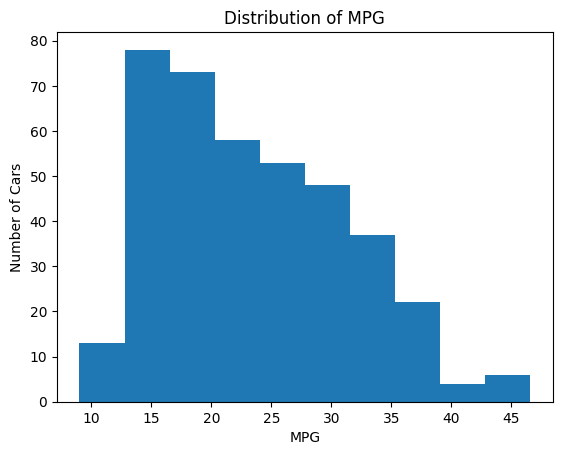

In [220]:
import matplotlib.pyplot as plt

plt.hist(df["mpg"], bins=10)
plt.xlabel("MPG")
plt.ylabel("Number of Cars")
plt.title("Distribution of MPG")
plt.show()

## 5. Vehicle Characteristics

In [221]:
df["weight"].describe()

,weight
count,392.000000
mean,2977.584184
std,849.402560
min,1613.000000
25%,2225.250000
50%,2803.500000
75%,3614.750000
max,5140.000000


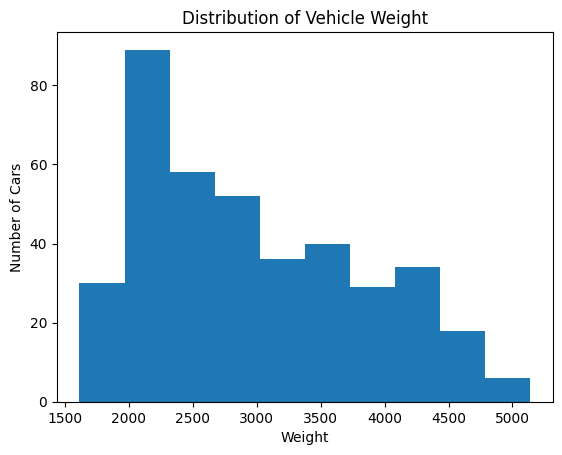

In [222]:
plt.hist(df["weight"], bins=10)
plt.xlabel("Weight")
plt.ylabel("Number of Cars")
plt.title("Distribution of Vehicle Weight")
plt.show()

In [223]:
df["acceleration"].describe()

,acceleration
count,392.000000
mean,15.541327
std,2.758864
min,8.000000
25%,13.775000
50%,15.500000
75%,17.025000
max,24.800000


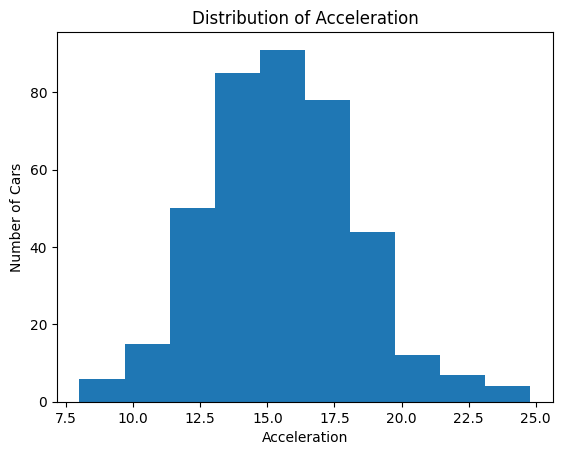

In [224]:
plt.hist(df["acceleration"], bins=10)
plt.xlabel("Acceleration")
plt.ylabel("Number of Cars")
plt.title("Distribution of Acceleration")
plt.show()

## 6. Relationships with MPG

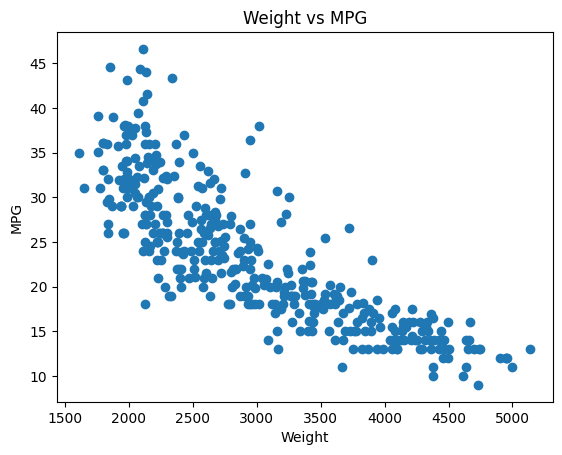

In [225]:
plt.scatter(df["weight"], df["mpg"])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Weight vs MPG")
plt.show()

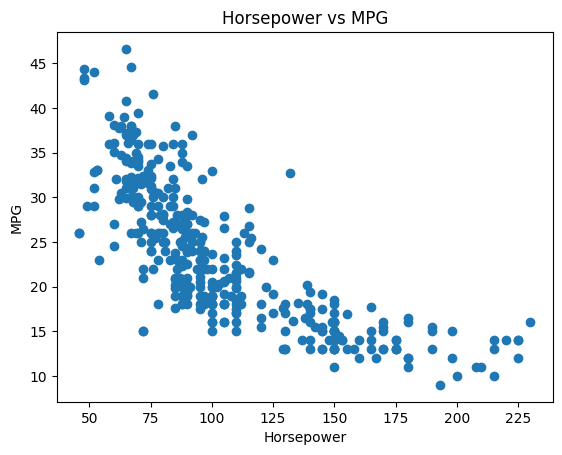

In [226]:
plt.scatter(df["horsepower"], df["mpg"])
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

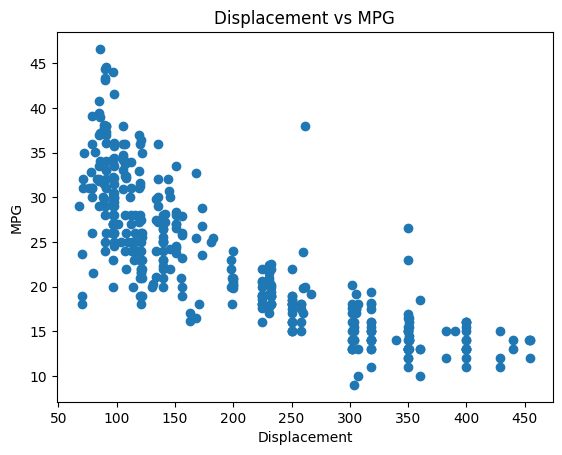

In [227]:
plt.scatter(df["displacement"], df["mpg"])
plt.xlabel("Displacement")
plt.ylabel("MPG")
plt.title("Displacement vs MPG")
plt.show()

## 7. MPG by Number of Cylinders

In [228]:
df.groupby("cylinders")["mpg"].mean()


,mpg
cylinders,
3,20.550000
4,29.283920
5,27.366667
6,19.973494
8,14.963107


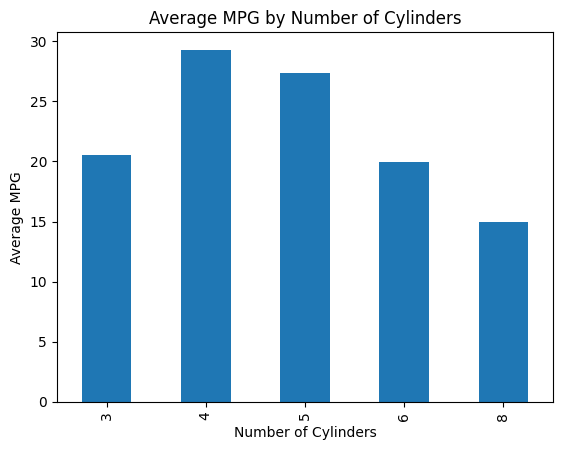

In [229]:
cylinder_mpg = df.groupby("cylinders")["mpg"].mean()

cylinder_mpg.plot(kind="bar")
plt.xlabel("Number of Cylinders")
plt.ylabel("Average MPG")
plt.title("Average MPG by Number of Cylinders")
plt.show()

## 8. Correlation Analysis

In [230]:
correlation = df.corr(numeric_only=True)

correlation

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


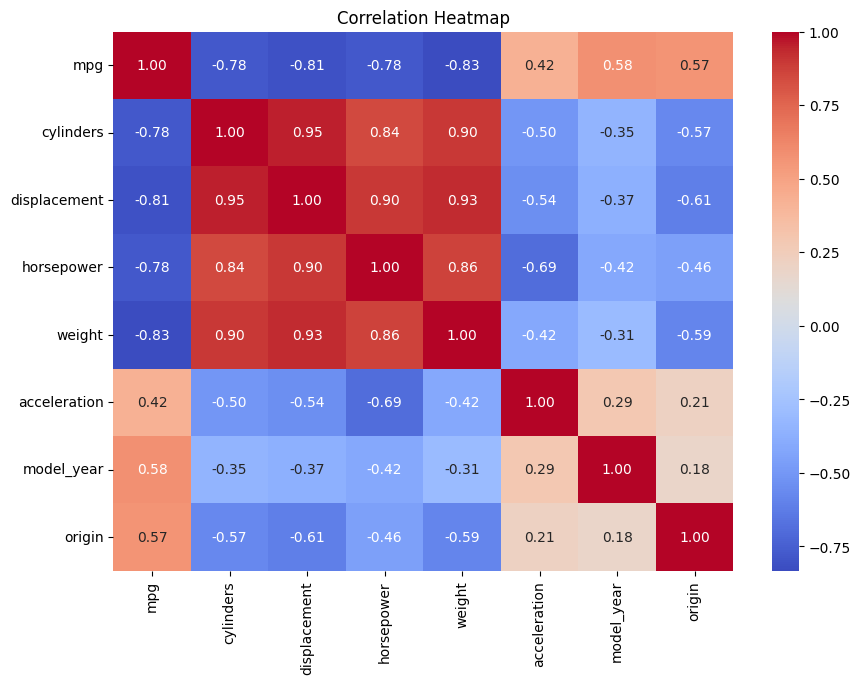

In [231]:
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 9. Outlier Check

In [232]:
Q1 = df["mpg"].quantile(0.25)
Q3 = df["mpg"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 17.0
Q3: 29.0
IQR: 12.0
Lower bound: -1.0
Upper bound: 47.0


In [233]:
Q1 = df["weight"].quantile(0.25)
Q3 = df["weight"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 2225.25
Q3: 3614.75
IQR: 1389.5
Lower bound: 141.0
Upper bound: 5699.0


## 10. Unusual Observation

The IQR method did not identify any statistical outliers in MPG or weight. However, we also looked for unusual combinations of values. One car had high MPG despite having relatively high displacement, so it was inspected separately.

In [234]:
df[(df["displacement"] > 250) & (df["mpg"] > 35)]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
387,38.0,6,262.0,85.0,3015.0,17.0,82,1,oldsmobile cutlass ciera (diesel)


## 11. Additional Analysis — Model Year vs MPG

In [235]:
year_mpg = df.groupby("model_year")["mpg"].mean()

year_mpg

,mpg
model_year,
70,17.689655
71,21.111111
72,18.714286
73,17.100000
74,22.769231
75,20.266667
76,21.573529
77,23.375000
78,24.061111


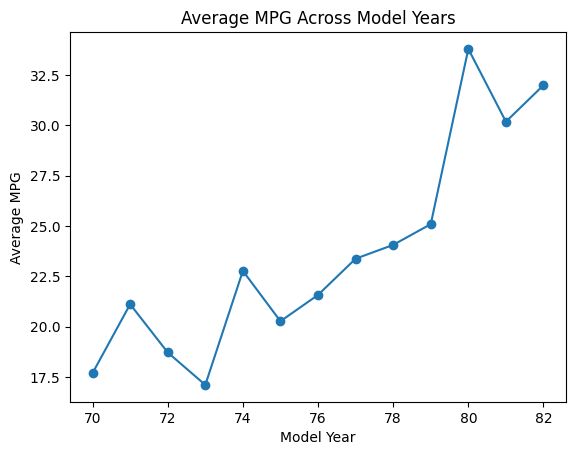

In [236]:
plt.plot(year_mpg.index, year_mpg.values, marker="o")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.title("Average MPG Across Model Years")
plt.show()

In [237]:
df.shape

(392, 9)

## 12. Task 1 — Key Findings

1. Most cars have an MPG value between roughly 13 and 35, while very high-MPG cars are less common.

2. Weight has a strong negative relationship with MPG. Heavier cars generally have lower MPG.

3. Horsepower also has a negative relationship with MPG. Cars with higher horsepower generally have lower MPG.

4. Displacement has a strong negative relationship with MPG. Cars with larger engine displacement generally have lower MPG.

5. Average MPG differs across cylinder groups. In our data, 4-cylinder cars had the highest average MPG, while 8-cylinder cars had the lowest.

6. Average MPG generally increased from 1970 to 1982, although it changed from year to year.

7. One unusual observation was the Oldsmobile Cutlass Ciera diesel, which had 38 MPG despite having 6 cylinders and 262 displacement. It was unusual compared with the general displacement-MPG pattern.

In [238]:
df.to_csv("auto-mpg-cleaned.csv", index=False)
from google.colab import files
files.download("auto-mpg-cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task 2 — Linear Regression

### Multiple Linear Regression

The simple model used only weight. Now, we use multiple vehicle features to see whether they can improve MPG prediction. The car_name column is removed because it is a text identifier, and origin is encoded as categorical data.

In [239]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [240]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [241]:
X = df[["weight"]]
y = df["mpg"]
print(X.head())
print(y.head())

   weight
0  3504.0
1  3693.0
2  3436.0
3  3433.0
4  3449.0
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [242]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [243]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (313, 1)
Testing data: (79, 1)


In [244]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [245]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -0.007903610385225605
Intercept: 47.200526427552106


In [246]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[29.89952329 25.1099354  32.97402773 31.74896812 25.14945345]


In [247]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 3.4641211922147592
MSE: 17.693388269545686
RMSE: 4.206350944648542
R²: 0.6533466675646016


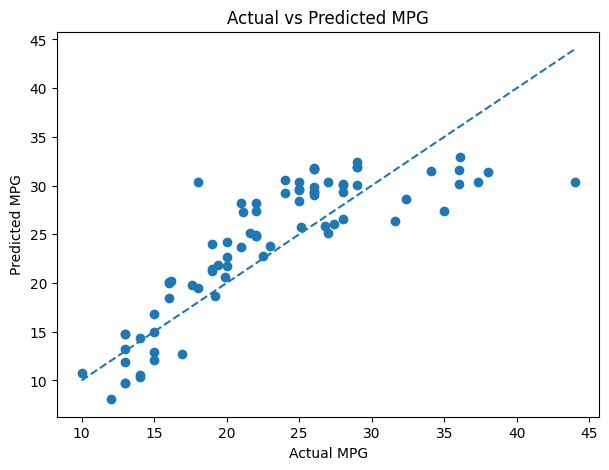

In [248]:


plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()


In [249]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.6981745885310532
Testing R²: 0.6533466675646016


In [250]:
df_ml = df.drop(columns=["car_name"]).copy()

df_ml = pd.get_dummies(
    df_ml,
    columns=["origin"],
    drop_first=True,
    dtype=int
)

df_ml.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0


In [251]:
X_multi = df_ml.drop(columns=["mpg"])
y_multi = df_ml["mpg"]

print("Features:")
print(X_multi.head())

print("\nTarget:")
print(y_multi.head())

Features:
   cylinders  displacement  horsepower  weight  acceleration  model_year  \
0          8         307.0       130.0  3504.0          12.0          70   
1          8         350.0       165.0  3693.0          11.5          70   
2          8         318.0       150.0  3436.0          11.0          70   
3          8         304.0       150.0  3433.0          12.0          70   
4          8         302.0       140.0  3449.0          10.5          70   

   origin_2  origin_3  
0         0         0  
1         0         0  
2         0         0  
3         0         0  
4         0         0  

Target:
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [252]:


X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_multi_train.shape)
print("Testing data:", X_multi_test.shape)

Training data: (313, 8)
Testing data: (79, 8)


In [253]:
multi_model = LinearRegression()

multi_model.fit(X_multi_train, y_multi_train)

LinearRegression()

In [254]:
y_multi_pred = multi_model.predict(X_multi_test)

print(y_multi_pred[:5])

[26.62308629 26.90246949 34.26598184 24.44117617 28.23541424]


In [255]:
mae_multi = mean_absolute_error(y_multi_test, y_multi_pred)
mse_multi = mean_squared_error(y_multi_test, y_multi_pred)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_multi_test, y_multi_pred)

print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R²:", r2_multi)

MAE: 2.461999698066141
MSE: 10.602279011688328
RMSE: 3.256114096847395
R²: 0.7922774714022589


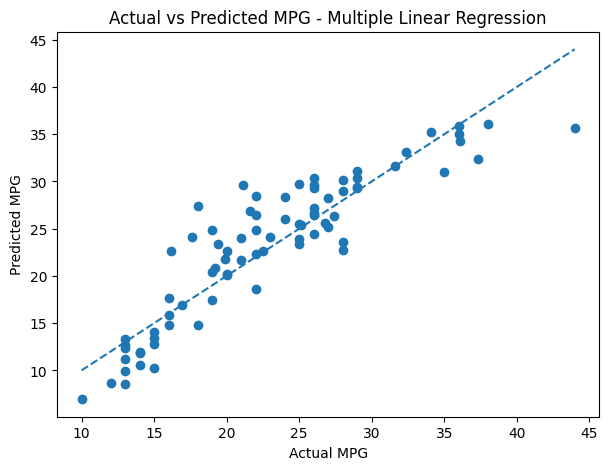

In [256]:
plt.figure(figsize=(7, 5))

plt.scatter(y_multi_test, y_multi_pred)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG - Multiple Linear Regression")

plt.plot(
    [y_multi_test.min(), y_multi_test.max()],
    [y_multi_test.min(), y_multi_test.max()],
    linestyle="--"
)

plt.show()

In [257]:
multi_train_pred = multi_model.predict(X_multi_train)
multi_test_pred = multi_model.predict(X_multi_test)

multi_train_r2 = r2_score(y_multi_train, multi_train_pred)
multi_test_r2 = r2_score(y_multi_test, multi_test_pred)

print("Training R²:", multi_train_r2)
print("Testing R²:", multi_test_r2)

Training R²: 0.8286865575852229
Testing R²: 0.7922774714022589


### Interpretation of Evaluation Metrics

- **MAE:** The multiple-feature model has an average absolute prediction error of about 2.46 MPG.
- **MSE:** MSE is about 10.60. It gives more weight to larger prediction errors because the errors are squared.
- **RMSE:** RMSE is about 3.26 MPG, meaning the typical prediction error is around 3.26 MPG, with larger errors having more influence.
- **R²:** The model has an R² of about 0.79 on the test data, meaning the model explains about 79% of the variation in MPG in the test set.

## Task 2 — Key Findings

1. Weight has a strong relationship with MPG. The weight-only model got an R² of about 0.65, so weight alone explains a good part of the variation in MPG.

2. Using more features improved the model. When we used features like cylinders, displacement, horsepower, weight, acceleration, model year and origin, the R² increased to about 0.79.

3. The multiple-feature model made smaller errors than the weight-only model. Its MAE decreased from 3.46 to 2.46 MPG, and RMSE decreased from 4.21 to 3.26 MPG.

4. The training and testing R² values were 0.83 and 0.79. Since the difference is small, there is no strong sign of overfitting.

5. Most points in the Actual vs Predicted graph are close to the diagonal line. This means the model's predictions are generally close to the actual MPG values, although some errors are still present.

6. Some features are strongly related to each other. For example, weight, horsepower, displacement and cylinders show strong correlations, so they may provide some overlapping information to the model.

## Task 2 — Limitations

1. The dataset is relatively small, with only 392 usable rows after removing missing horsepower values.

2. Linear Regression assumes a linear relationship between the features and MPG, so it may not capture more complex relationships.

3. Some features such as cylinders, displacement, horsepower and weight are strongly related to each other, which can make it difficult to understand the individual effect of each feature.

## Task 2 — Possible Improvement

A possible improvement would be to try a non-linear model such as Random Forest Regression. It may be able to capture more complex relationships between vehicle features and MPG that Linear Regression may miss.